Phase 2A:
Multi-step LSTM Forecaster - predict next 1 hour

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [2]:
# Load feature dataset
cpu_df = pd.read_csv(
    "../data/Processed/cpu_baseline.csv"
)

In [3]:
# convert timestamp
cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)
# Sort
cpu_df = cpu_df.sort_values(
    ["hostName","ts"]
)

In [4]:
# Forecast features
FEATURES = [
    "cpu_usage_pct",
    "memory_usage_pct",
    "power_kw",
    "cpu_temp_c",
    "resource_stress_index",
    "cpu_change",
    "cpu_acceleration",
    "cpu_volatility",
    "cpu_per_kw",
    "hour_of_day",
    "day_of_week",
    "is_weekend"
]
TARGET = "cpu_usage_pct"

# Scale
scaler = MinMaxScaler()

cpu_df[FEATURES] = scaler.fit_transform(
    cpu_df[FEATURES]
)

In [5]:
# Create multi-step sequences
# Forecast = 12 timestamps -> 1 hour
LOOKBACK = 72
FORECAST = 12
X = []
y = []

for host in cpu_df["hostName"].unique():

    server = cpu_df[
        cpu_df["hostName"] == host
    ]
    values = server[FEATURES].values
    target = server[TARGET].values
    for i in range(
        LOOKBACK,
        len(server)-FORECAST
    ):
        X.append(
            values[
                i-LOOKBACK:i
            ]
        )
        y.append(
            target[
                i:i+FORECAST
            ]
        )

X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

(74000, 72, 12)
(74000, 12)


In [6]:
# Train/test split
split = int(
    len(X)*0.8
)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [7]:
# Model
model = Sequential()
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X.shape[1],
            X.shape[2]
        )
    )
)
model.add(
    Dropout(0.2)
)
model.add(
    LSTM(32)
)
model.add(
    Dropout(0.2)
)
model.add(
    Dense(32)
)
model.add(
    Dense(12)
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
model.summary()

c:\Users\Avilasha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,580 (131.17 KB)

 Trainable params: 33,580 (131.17 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Predict
pred = model.predict(
    X_test
)

Epoch 1/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - loss: 0.0017 - mae: 0.0239 - val_loss: 9.8729e-04 - val_mae: 0.0189
Epoch 2/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 8.0341e-04 - mae: 0.0159 - val_loss: 8.9335e-04 - val_mae: 0.0165
Epoch 3/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - loss: 7.4680e-04 - mae: 0.0146 - val_loss: 8.6022e-04 - val_mae: 0.0159
Epoch 4/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - loss: 7.3079e-04 - mae: 0.0143 - val_loss: 7.9719e-04 - val_mae: 0.0140
Epoch 5/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - loss: 7.2331e-04 - mae: 0.0141 - val_loss: 7.7487e-04 - val_mae: 0.0134
Epoch 6/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - loss: 7.1812e-04 - mae: 0.0140 - val_loss: 7.5897e-04 - val_mae: 0.0126
Epoch 7/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - loss: 7.1740e-04 - mae: 0.0140 - val_loss: 8.0903e-04 - val_mae: 0.0143
Epoch 8/30
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 7.1158e-04 - mae: 0.0139 - val_loss: 7.8603e-0

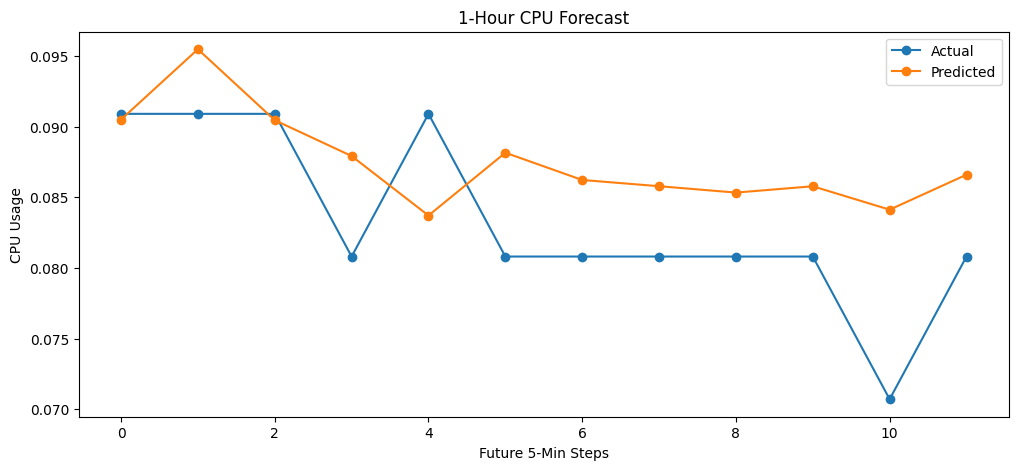

In [ ]:
# First FORECAST
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test[0],
    marker="o",
    label="Actual"
)

plt.plot(
    pred[0],
    marker="o",
    label="Predicted"
)

plt.title(
    "1-Hour CPU Forecast"
)

plt.xlabel(
    "Future 5-Min Steps"
)

plt.ylabel(
    "CPU Usage"
)

plt.legend()

plt.show()

In [16]:
test_start_idx = split

print(
    cpu_df.iloc[
        test_start_idx + LOOKBACK :
        test_start_idx + LOOKBACK + 12
    ][["ts","cpu_usage_pct"]]
)

                                    ts  cpu_usage_pct
59272 2026-04-20 04:18:22.160000+00:00       0.080808
59273 2026-04-20 04:23:23.370000+00:00       0.080808
59274 2026-04-20 04:28:23.992000+00:00       0.080808
59275 2026-04-20 04:33:22.194000+00:00       0.080808
59276 2026-04-20 04:38:23.904000+00:00       0.101010
59277 2026-04-20 04:43:24.045000+00:00       0.080808
59278 2026-04-20 04:48:21.980000+00:00       0.101010
59279 2026-04-20 04:53:28.349000+00:00       0.080808
59280 2026-04-20 04:58:22.147000+00:00       0.101010
59281 2026-04-20 05:03:22.025000+00:00       0.080808
59282 2026-04-20 05:08:22.610000+00:00       0.080808
59283 2026-04-20 05:13:22.821000+00:00       0.080808


In [10]:
# Evaltuation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test.flatten(),
    pred.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        y_test.flatten(),
        pred.flatten()
    )
)

r2 = r2_score(
    y_test.flatten(),
    pred.flatten()
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.013940964439286828
RMSE: 0.033718876091006066
R²  : 0.41702763350642635
